In [1]:
%pip install jupysql duckdb duckdb-engine --quiet

%load_ext sql
%sql duckdb:///:memory:

Note: you may need to restart the kernel to use updated packages.


Connecting to 'duckdb:///:memory:'

In [2]:
%%sql
create table bookings as select * from read_csv_auto('bookings.csv');
create table clients as select * from read_csv_auto('clients.csv');

Running query in 'duckdb:///:memory:'

Count
50


In [7]:
%%sql task_7_gmv_by_month <<
select
    extract(month from booking_date) as month,
    round(sum(amount_rub),2) as gmv
from bookings
where status = 'confirmed'
group by month
order by month

Running query in 'duckdb:///:memory:'

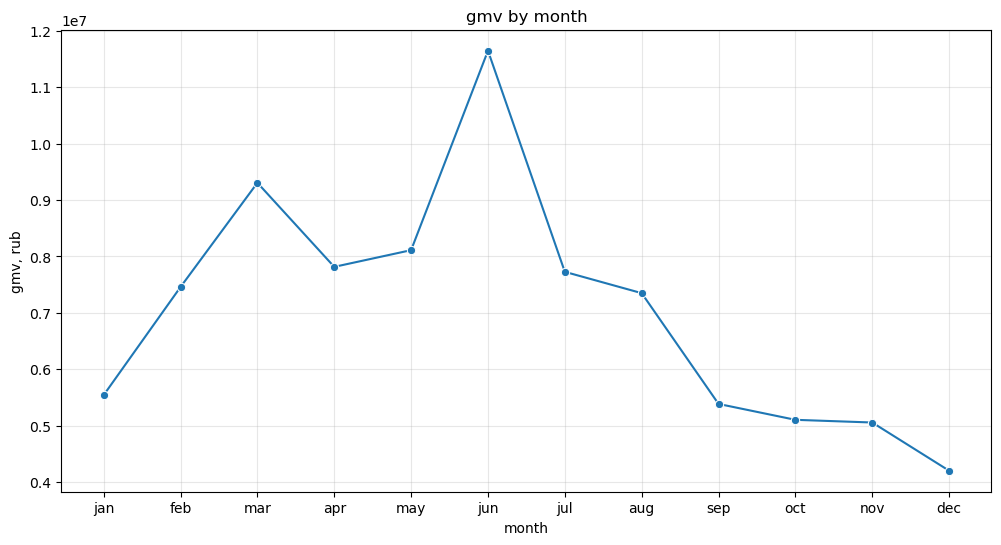

In [8]:
df_task_7_gmv_by_month = task_7_gmv_by_month.DataFrame()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

month_map = {
    1: 'jan', 2: 'feb', 3: 'mar', 4: 'apr',
    5: 'may', 6: 'jun', 7: 'jul', 8: 'aug',
    9: 'sep', 10: 'oct', 11: 'nov', 12: 'dec'
}

df_task_7_gmv_by_month['month_name'] = df_task_7_gmv_by_month['month'].map(month_map)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_task_7_gmv_by_month,
    x='month_name',
    y='gmv',
    marker='o'
)

plt.title('gmv by month')
plt.xlabel('month')
plt.ylabel('gmv, rub')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
Динамика общего gmv по всем тирам, по всем субпродуктам в течение года. По сути главная метрика бизнеса.

In [37]:
%%sql task_7_cacancelled_rate_by_month <<
with cancelled_rate as (
    select
        extract(month from booking_date) as month,
        count(*) as bookings_counts,
        sum(case when status = 'cancelled' then 1 else 0 end) as cancelled_booking_counts
    from bookings
    group by month
)
select
    month,
    round(1.0 * cancelled_booking_counts / bookings_counts, 4) as cancelled_rate
from cancelled_rate
order by month

Running query in 'duckdb:///:memory:'

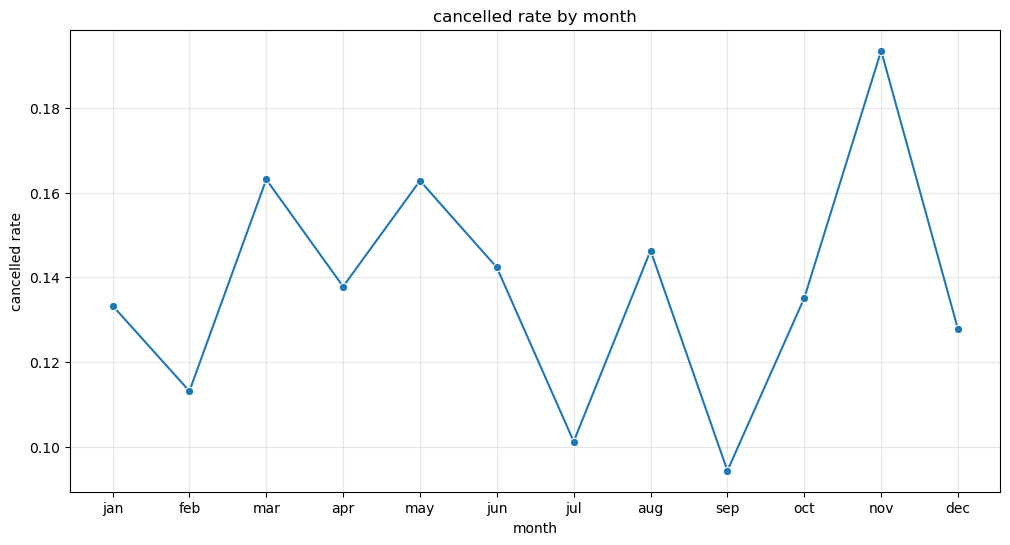

In [38]:
df_task_7_cacancelled_rate_by_month = task_7_cacancelled_rate_by_month.DataFrame()

month_map = {
    1: 'jan', 2: 'feb', 3: 'mar', 4: 'apr',
    5: 'may', 6: 'jun', 7: 'jul', 8: 'aug',
    9: 'sep', 10: 'oct', 11: 'nov', 12: 'dec'
}

df_task_7_cacancelled_rate_by_month['month_name'] = df_task_7_cacancelled_rate_by_month['month'].map(month_map)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_task_7_cacancelled_rate_by_month,
    x='month_name',
    y='cancelled_rate',
    marker='o'
)

plt.title('cancelled rate by month')
plt.xlabel('month')
plt.ylabel('cancelled rate')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
Динамика доли отмененных бронирований в течение года. 
У меня была гипотеза, что падение общего gmv в период с июня по сентябрь связано с ростом отмененных бронирований.
Этот график показывает, что моя гипотеза неверна.

In [27]:
%%sql task_7_gmv_by_tier << 

with bookings_with_tier as (
    select 
        booking_id,
        a.client_id as client_id, 
        subproduct,
        booking_date,
        trip_date,
        amount_rub,
        status,
        tier
    from bookings as a left join clients as b
    on a.client_id = b.client_id
    where status = 'confirmed'
)

select
    tier,
    extract(month from booking_date) as month,
    round(sum(amount_rub),2) as gmv_tier
from bookings_with_tier
group by tier, month

Running query in 'duckdb:///:memory:'

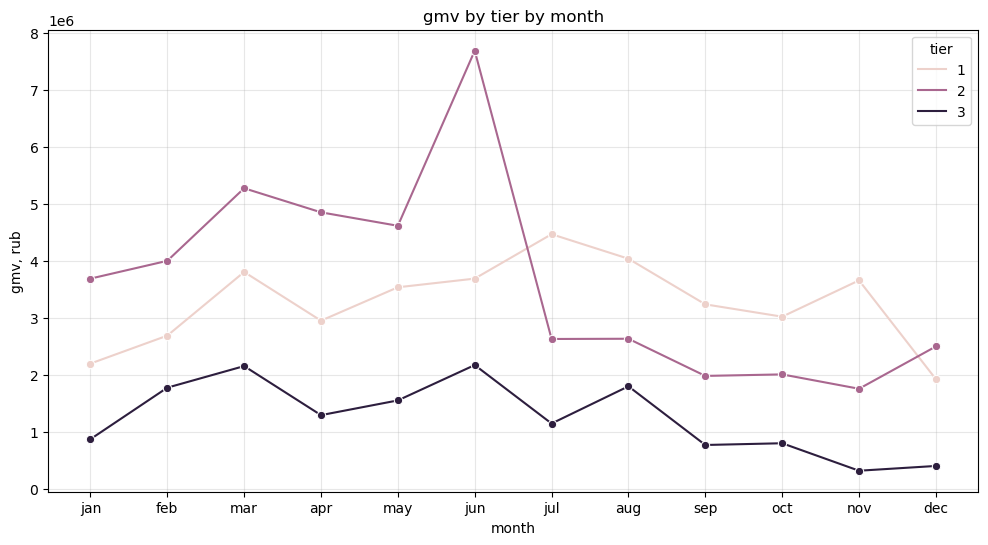

In [28]:
df_task_7_gmv_by_tier_by_month = task_7_gmv_by_tier_by_month.DataFrame()

month_map = {
    1: 'jan', 2: 'feb', 3: 'mar', 4: 'apr',
    5: 'may', 6: 'jun', 7: 'jul', 8: 'aug',
    9: 'sep', 10: 'oct', 11: 'nov', 12: 'dec'
}

df_task_7_gmv_by_tier_by_month['month_name'] = df_task_7_gmv_by_tier_by_month['month'].map(month_map)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_task_7_gmv_by_tier_by_month,
    x='month_name',
    y='gmv_tier',
    hue='tier',
    marker='o'
)

plt.title('gmv by tier by month')
plt.xlabel('month')
plt.ylabel('gmv, rub')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
Динамика gmv для каждого тира в течение года.
Этот график показывает, как разные тиры клиентов вносят вклад в оборот по месяцам.

In [33]:
%%sql task_7_booking_counts_by_month <<

select 
    extract(month from booking_date) as month,
    count(*) as booking_counts_by_month
from bookings 
group by month

Running query in 'duckdb:///:memory:'

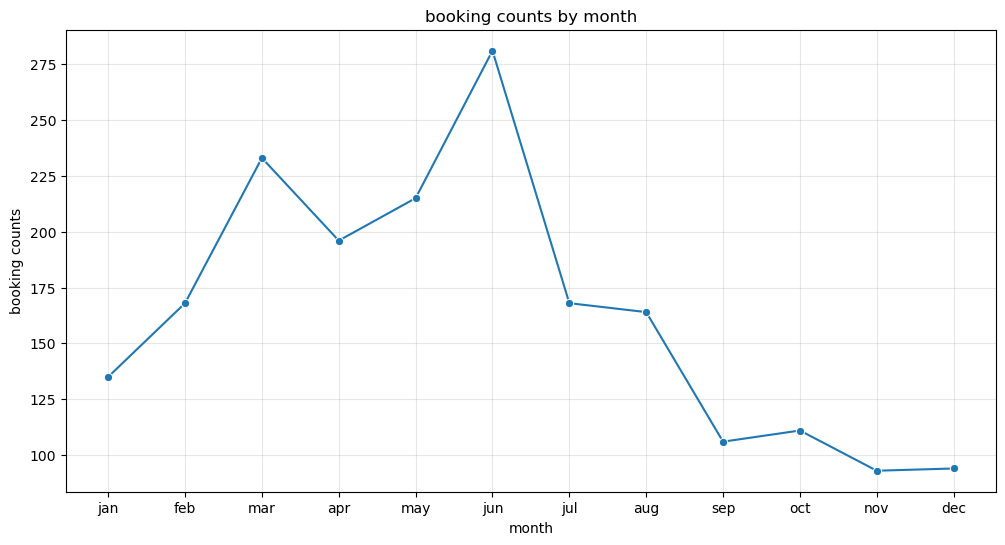

In [35]:
df_task_7_booking_counts_by_month = task_7_booking_counts_by_month.DataFrame()

month_map = {
    1: 'jan', 2: 'feb', 3: 'mar', 4: 'apr',
    5: 'may', 6: 'jun', 7: 'jul', 8: 'aug',
    9: 'sep', 10: 'oct', 11: 'nov', 12: 'dec'
}

df_task_7_booking_counts_by_month['month_name'] = df_task_7_booking_counts_by_month['month'].map(month_map)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_task_7_booking_counts_by_month,
    x='month_name',
    y='booking_counts_by_month',
    marker='o'
)

plt.title('booking counts by month')
plt.xlabel('month')
plt.ylabel('booking counts')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
Динамика количества бронирований в течение года.
Другими словами, этот график показывает динамику спроса на сервис в течение года.